# Quick Start

BrainDance's mission is to open the field of biological computing to all, allowing users to both write experiments of their own to be run on organic tissue or analyze data from either their own research or our expansive catalogue of openly available neural tissue recordings. 

The goal of this document is to give you a basic rundown of how to set up and use BrainDance, with short tutorials on basic functions all tied together in a greater analysis-based experiment. This is done in an effort to quickly get you accustomed to the code's use. We will go into how to load neural recordings and then provide you with examples of some of our most basic built-in plotting tools that can be used at the start of any of your own analyses. We then show basic steps to combine these into more manifold data representations. This document can also serve as inspiration for your own first passes at experimental analysis and perhaps future research!


For these tutorials we will be performing stimulus-evoked latency analysis on data recorded by the Braingeneers' lab to identify neurons that respond to stimulation. Like most of our data, these recordings were taken on a Maxwell Biosystems' MaxOne HDMEA plate which you can learn more about [here](https://www.mxwbio.com/technology/?gclid=Cj0KCQjwr82iBhCuARIsAO0EAZw9HkpNG65Ot-iM4ZKitSkEYj4utIb3EXS6lGWZbp6G9ABrDn2UChEaAsy8EALw_wcB). The culture recorded is a cortical organoid, a group of neurons grown from mouse stem cells in the Braingeneers' Lab. Cortical organoids are a simplistic model of brain-like behavior but provide an excellent testing bed for how these networks learn and respond to external stimuli. 

The recording we will be examining in this tutorial is an example of cartpole training, in which we have the organoid balance a pole by moving a cart side to side in a virtual environment. To do this the organoid has two neurons which operate as encode neurons, and two which operate as decode neurons. The encode neurons take inputs from the virtual environment to the organoid, here we encode the lean of the pole in either the left direction (sent to input 1) or the right direction (input 2), stimulating based on the degree to which the pole leans to either side (rate encoding). The decode neurons, then, control which direction to move the cart (decoding through spike differentials), once again left or right, direction dictated by each neuron. 

For a more in-depth explanation of how to train an organoid to play cartpole and more information on interfacing with the organoid, we recommend you read [Goal-directed learning in cortical organoids](https://www.sciencedirect.com/science/article/pii/S2211124726000628) which fully explains all processes used in these sorts of experiments. 

#### Install :
Downloading braindance can be done several ways, the easyest is to up python's PIP : 

    > python -m pip install BrainDance

Alternatively, you can download it via github : 

    > git clone https://github.com/braingeneers/BrainDance
    > cd BrainDance
    > pip install -e.
    > cd .. 

This will also download any missing core dependencies. Packages that are not considered core are those that pertain to specialtu use of RT-Sort, Kilosort2, or Open Ephys. These will not be required for this tutorial but should you need to install these please refer to [this page](https://github.com/braingeneers/BrainDance/tree/main).

**Note :** If you are following along with this tutorial's Jupyter Notebook you may need to restart your workspace's kernel to ensure the package works within your working environment. 

#### Configuration :

You must also run the setup command in your working directory as well and configure your data directory and catalogue paths. 

Run the setup command first (see README.md):

    > python -m braindance.utils.data_manager setup 
        --data-dir /your/path/to/data 
        --catalog /your/path/to/catalog.csv

#### Importing : 

Run the cell below to import the packages required for this tutorial : 

In [4]:
import numpy as np 
from braindance.utils.data_manager import load_recording, calculate_latencies

- `load_recording` : allows us to load, use, and analyze BrainDance's primary datatype `recording`, neural recordings from Braingeneer's wetlab with lazy-loaded data and automatic results caching. 
- `calculate_latencies` : Used in a later data analysis technique, calculates the latencies between two neurons firing for all pairs in the culture. 

## Loading Data

#### Data Access Architecture : 

While other institutions may use different access hierarchies, this tutorial will use data made available by UCSC's Braingeneers. Our data follows a strict access hierarchy that you should become accustomed to. Every dataset provided follows the hierarchy :

    Project
        └── Chip
            └── Experiment
                └── Recording

**Project :** The project is a combination of multiple experiments being run on multiple chips, a project will usually have one overarching goal.

**Chip :** Within the project folder will be a series of folders, one for each chip used in the project. These are labeled using the chip ID, and will contain all recordings done by that chip. Specifications on the MaxOne chips used by Braingeneer's for our recordings can be found on Maxwell Biosystem's [user guide](https://www.mxwbio.com/resources/maxone-guide).

"Chip" refers to a unique piece of biology, we call it this because usually a single chip has a single biological experiment, if the same physical chip is reused, our preference is to add an a/b/c to the end of the chip name in order to distinguish and keep track of usage. In essence however the chip and cultures name are interchangeable, i.e. the organoids are named for where they live.

**Experiment :** Chips may run more than one experiment per project and thus all experiments will be stored within the corresponding chip folder. It is from these experiments that BrainDance loads it's recordings. Experiments can contain multiple recordings, but they are grouped under a single experiment by shared purpose. The recordings under a single experiment are testing the same hypothesis.

For a more in depth explanation of BrainDance's data organization please refer to the [this guide](https://github.com/braingeneers/BrainDance-dev/blob/main/docs/Organizing_Data.md) from BrainDance's user documentation .

#### Loading Data into Workspace :

Now we can load our data from braingeneer's s3, first we set our variables, the project, chip, and experiment, along with a base path which allows our data loader to draw from the s3 database. 

In [ ]:
proj = "24-04-18_butterfly"
chip = "23133"
experiment = "exp1"
recording = "exp1_cartpole_long_3"
exp_rec = f"{experiment}/{recording}"
base_path = f"s3://braingeneersdev/asrobbin/braindance_data/{proj}"

<font color='red'>**NOTE :** an in development version of recording will take `experiment` and `recording` as separate entires when running commands, for now we will just combine them into a single `exp_rec` var.

With these set we can load the data: 

In [5]:
rec = load_recording(proj, chip, exp_rec, base_path=base_path)
print(f"✓ Recording loaded: {rec.identifier}")

✓ Recording loaded: 24-04-18_butterfly/23133/exp1/exp1_cartpole_long_3


## Data Analysis

#### Spikedata :

From our recording we can now load our `spikedata`, a class developed by Braingeneer's which encodes the spike train of all neurons in a recording. A spike train encodes an action potential, otherwise known as a spike or firing event, in an array where each entry is a millisecond in the recording, a 0 means there was no spike in that millisecond window, however a 1 indicates the neuron fired in that timestep. The `spikedata` holds a train for every neuron in the culture. 

In [6]:
spikes = rec.spikes

The `spikedata` class also contains additional information that can be important to analysis, for specifics please review this [WIP page](), but for the time being let's access the number of neurons in the recording and the recording duration :

In [7]:
print(f"  Number of neurons: {spikes.N}")
print(f"  Recording duration: {spikes.length / 1000:.1f} seconds ({spikes.length} ms)")

  Number of neurons: 292
  Recording duration: 900.0 seconds (899980.0 ms)


We can also examine the spike train more closely by looking at the first neuron in the dataset, this can be done with any neuron in the culture :

In [8]:
neuron_0_spikes = spikes.train[0]
print(f"\nNeuron 0:")
print(f"  Total spikes: {len(neuron_0_spikes)}")
print(f"  First 5 spike times (ms): {neuron_0_spikes[:5]}")
print(f"  Firing rate: {len(neuron_0_spikes) / (spikes.length / 1000):.2f} Hz")


Neuron 0:
  Total spikes: 13192
  First 5 spike times (ms): [ 70.7   73.1  156.85 227.95 254.8 ]
  Firing rate: 14.66 Hz


Taking a step back, let's look at the entire dataset of neurons, first we'll calculate the firing rate of all neurons across the recording :

In [9]:
firing_rates = spikes.rates(unit="Hz")

print("\nFiring Rate Statistics:")
print(f"  Mean: {np.mean(firing_rates):.2f} Hz")
print(f"  Median: {np.median(firing_rates):.2f} Hz")
print(f"  Min: {np.min(firing_rates):.2f} Hz")
print(f"  Max: {np.max(firing_rates):.2f} Hz")

# How many neurons are active? (firing > 0.1 Hz)
active = np.sum(firing_rates > 0.1)
print(f"  Active neurons (>0.1 Hz): {active}/{len(firing_rates)}")



Firing Rate Statistics:
  Mean: 4.66 Hz
  Median: 2.17 Hz
  Min: 0.00 Hz
  Max: 36.95 Hz
  Active neurons (>0.1 Hz): 275/292


#### Spike Rasters :

We can visualize the spike train of our recording in a plot called a **spike raster**. Since the spike train of each neuron is just an array of 1s (spikes) and 0s (no spikes), we can create a scatter plot of firing events where the x axis is time (in seconds) through the length of the recording and the y axis are rows each representing a single neuron in the dataset. Spike rasters are some of the most basic plots used in analyzing SpikeData so it is worthwhile that you get accustomed to reading and creating them. Luckily, most of the latter is done by one of BrainDance's inbuilt plot accessor function : `rec.pl.raster_with_pop()`, calling it without any parameters will show you a spike raster of the entire recording, but with long recordings it can be hard to read so often it is important to specify the window of time you want to be looking at. Below we have a spike raster that shows the first 60 seconds of the recording, the black ticks represent *firing events* and the blue line is the *firing rate* of the entire neuron population. 

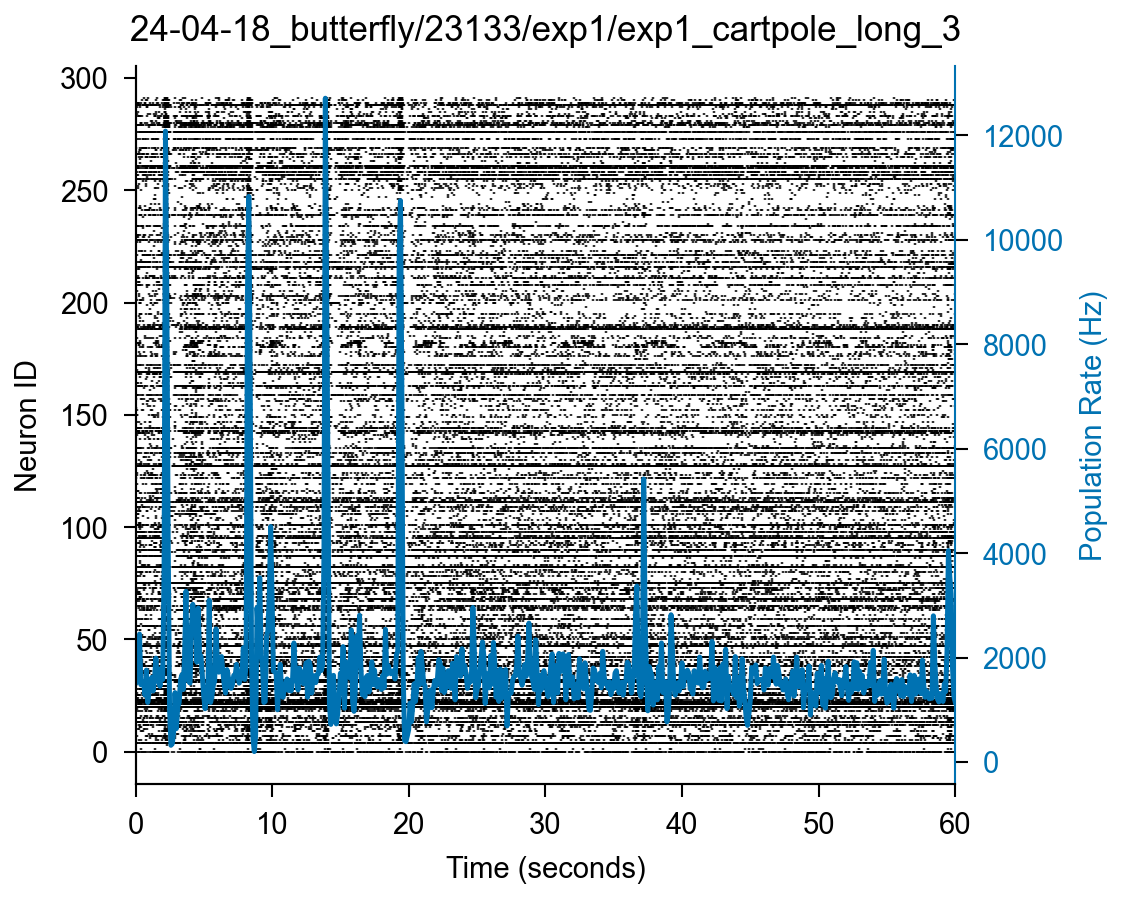

(<Figure size 1156.33x932.438 with 2 Axes>,
 (<Axes: title={'center': '24-04-18_butterfly/23133/exp1/exp1_cartpole_long_3'}, xlabel='Time (seconds)', ylabel='Neuron ID'>,
  <Axes: ylabel='Population Rate (Hz)'>))

In [21]:
rec.pl.raster_with_pop(time_window=(0, 60), 
                       time_unit='seconds', 
                       pop_rate_unit='Hz',
                       show=True)


# The above method will only display the plot. 
# You can also save directly to a specified path by 
# providing `save_path` and `filename` arguments:

# rec.pl.raster_with_pop(
#     time_window=(0, 60),
#     time_unit='seconds', 
#     pop_rate_unit='Hz',
#     save_path='./figures',
#     filename='raster_example'
# )


The blue line over the raster indicates the firing rate of the culture at that timestep, smoothed to be easily plotted. Notice where the firing rate dramatically increases, these events are known as bursts. A burst is defined as a short window of activity where the neurons are especially active. Neuroscientists are interested in bursts not just because they are the areas of most activity, but most importantly, because these regions display repeated patterns of consistent relationships between neurons. The population rate at this wide of a time window can tell us when burst occur, however it they are easier to distinguish when you zoom in on the dataset, alongside this doing so provides more information on the firing patterns within the bursts.

Using the function `rec.pl.raster_with_pop()` try zooming in on one of these bursts to a two second window. To do so, please complete the code below :

In [ ]:
rec.pl.raster_with_pop(
    # Your code here
)

If you need to generate a raster with only the spike event ticks then you can specify to plot the raster without the population rate using the parameter `show_pop_rate`. This is done as follows : 

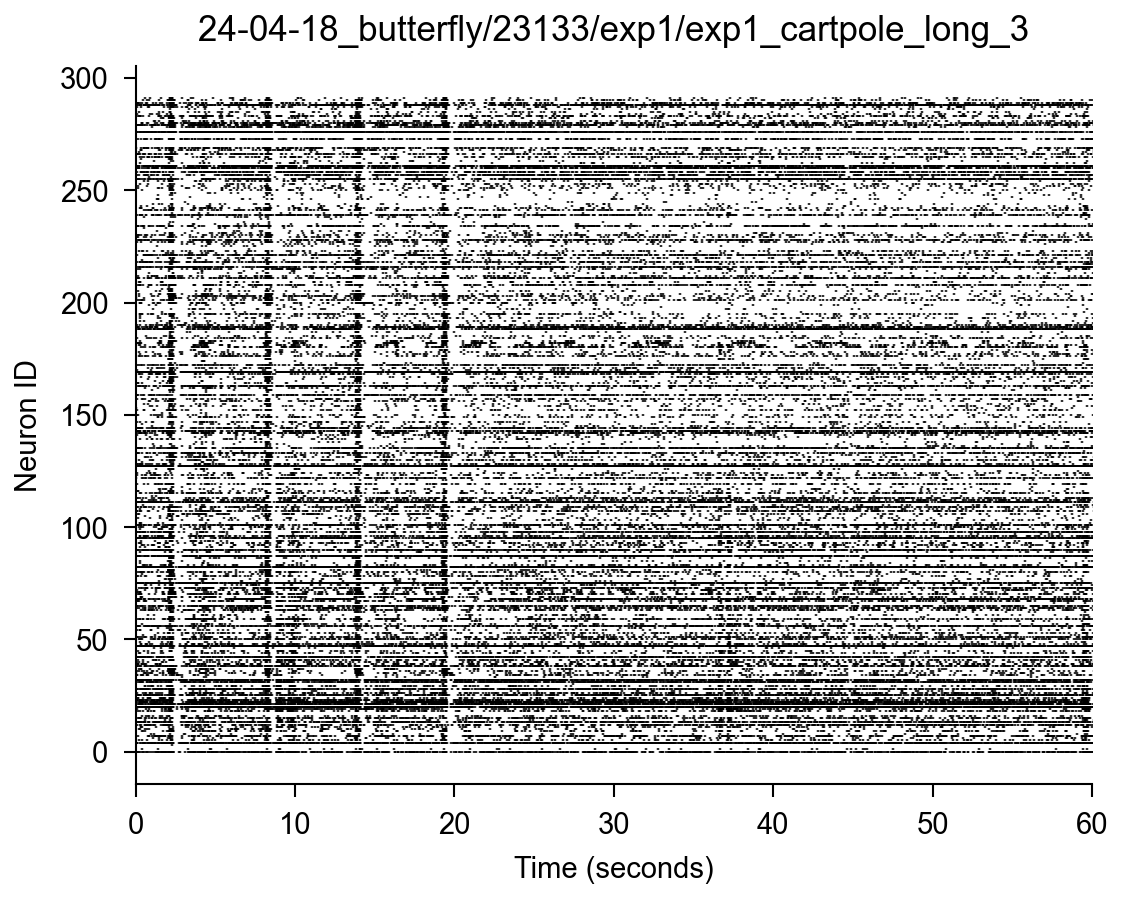

(<Figure size 1156.33x932.438 with 1 Axes>,
 (<Axes: title={'center': '24-04-18_butterfly/23133/exp1/exp1_cartpole_long_3'}, xlabel='Time (seconds)', ylabel='Neuron ID'>,
  None))

In [11]:
rec.pl.raster_with_pop(time_window=(0, 60), 
                       time_unit='seconds', 
                       show_pop_rate=False,           # Hide population rate
                       show=True)

#### Correlation :

Another basic analysis you should become accustom to running on experiment data is studying the inter-neuron correlation of the recording. This is best serviced via Spike Time Tiling Coefficient (STTC), a type of correlation matrix. An STTC matrix measures pairwise correlation between every individual neuron's spike trains. We use STTC instead of the correlation index because correlation index has inherent drawbacks that means it may be confounded by other statistical means like firing rate and then underperform when looking at different instances of correlation indices for different datasets, providing unreliable comparisons of datasets additionally correlation index is also unbounded above. 

STTC on the other hand uses a method of tiling to check how many times two neurons fire within the same tile of one another, with the tiling being done across the entire recording, to measures pairwise correlation between neuron spike trains. Like with the spike raster, BrainDance also includes a plot accessor function to plot the STTC, `rec.pl.sttc_matrix()`. This function will automatically compute the STTC of a recording, but it is both important you understand how to calculate the STTC and gives you more control on the tiling process to calculate it before hand and then feed it to `rec.pl.sttc_matrix()`.

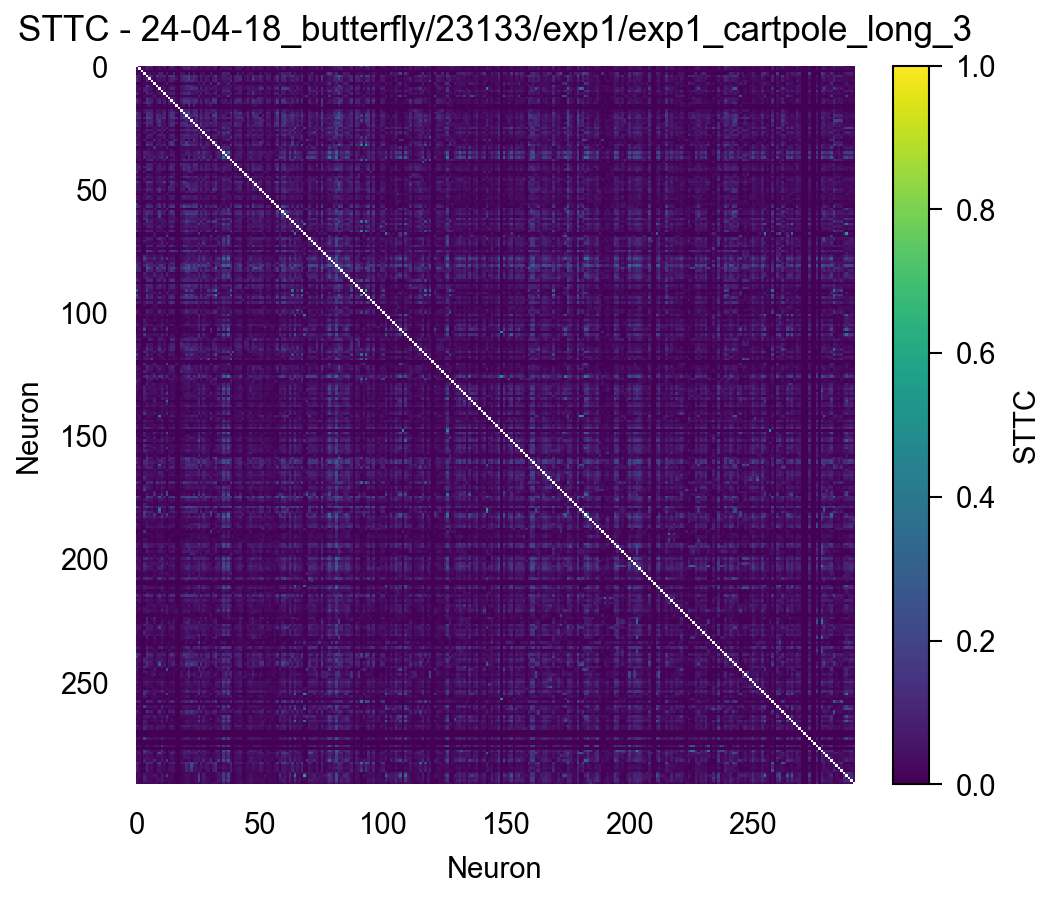

(<Figure size 1156.33x932.438 with 2 Axes>,
 <Axes: title={'center': 'STTC - 24-04-18_butterfly/23133/exp1/exp1_cartpole_long_3'}, xlabel='Neuron', ylabel='Neuron'>)

In [12]:
# Compute STTC directly using spikedata, then plot
sttc_matrix = spikes.spike_time_tilings(delt=20.0)  # underlying function from spikedata; delt = time window in ms

# The plotting function will automatically compute STTC if not provided but calculating above can give you more control
rec.pl.sttc_matrix(sttc_matrix=sttc_matrix, 
                    delt=20.0,
                    cmap='viridis',
                    vmin=0,
                    vmax=1,
                    show=True)

This plots a matrix where each cell displays the corelation to neuron index x to neuron index y, STTC is also symmetrical so this goes vice a versa. Green denotes positive correlation and blue is no correlation. The diagonal of the matrix is a neurons correlation to itself, which for all neurons is the maximum correlation, 1. 

The parameter `delt` controls the tiling window size, try adjusting `delt` to get a narrower correlation window, what changes?

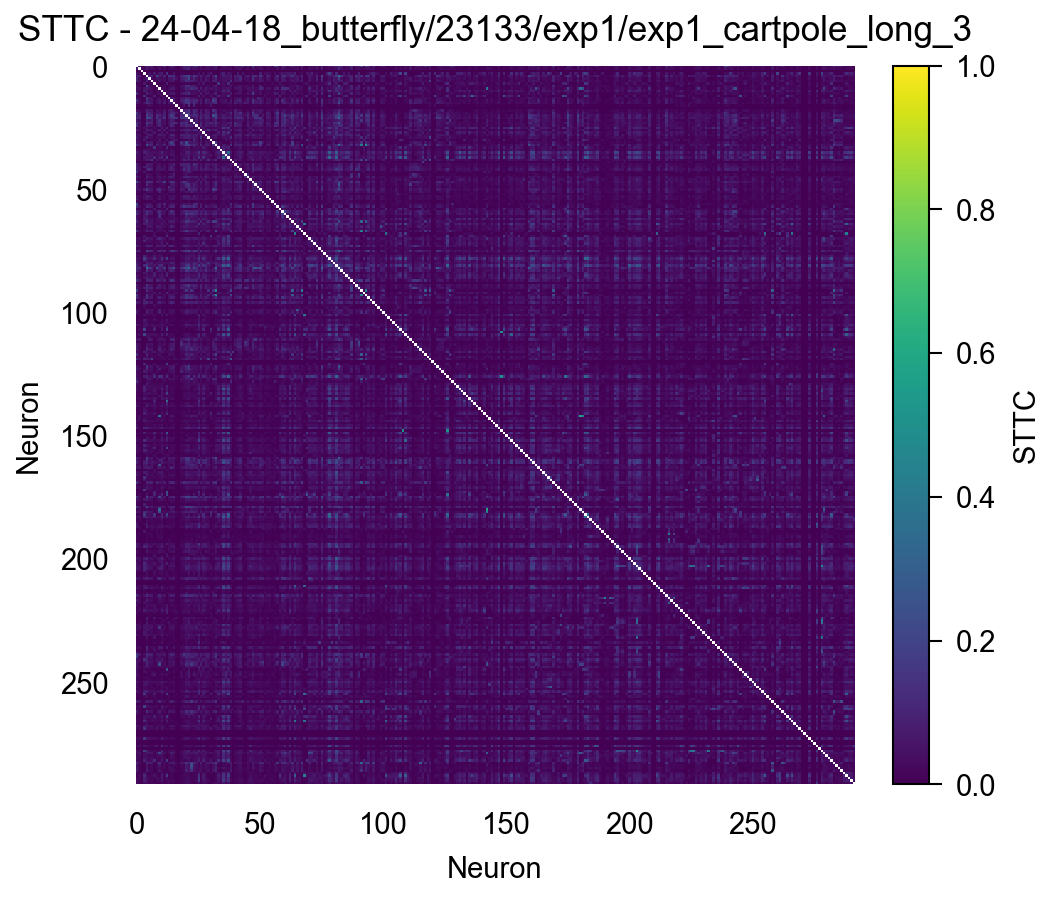

(<Figure size 1156.33x932.438 with 2 Axes>,
 <Axes: title={'center': 'STTC - 24-04-18_butterfly/23133/exp1/exp1_cartpole_long_3'}, xlabel='Neuron', ylabel='Neuron'>)

In [13]:
sttc_matrix = spikes.spike_time_tilings(delt=10.0)  # delt = time window in ms

rec.pl.sttc_matrix(sttc_matrix=sttc_matrix, 
                    delt=10.0,
                    cmap='viridis',
                    vmin=0,
                    vmax=1,
                    show=True)

#### Stimulations :

If any stimulation was done to the culture during an experiment, the recording will come with a stimulation log, this is a record of every stimulation done with the MEA to the culture. Looking at the stimulation log can tell you the location of stimulations across the culture, since it logs which electrodes where used for stimulation. These logs can be used to verify that an experiments stim procedures were followed, or have stim events used in plots to show how a culture's behavior changes in response. We can access the stimulation log with the following code : 

In [12]:
stim_log = rec.stim_log

if stim_log is not None and len(stim_log) > 0: # Check if recording has a stim_log 
    print(f"  Total stimulations: {len(stim_log)}")
    print(f"  Columns: {list(stim_log.columns)}")
    print("\nFirst 3 stimulations:")
    print(stim_log.head(3))
else:
    print("  No stimulation data available for this recording")

  Total stimulations: 2367
  Columns: ['time', 'amplitude', 'duty_time_ms', 'stim_electrodes', 'tag', 'time_mod']

First 3 stimulations:
       time amplitude  duty_time_ms stim_electrodes      tag  time_mod
0  2.092692       400           200   [21556, 8040]  sensory   2.09775
1  2.903603       400           200          [8040]  sensory   2.90730
2  3.432107       400           200          [8040]  sensory   3.43580


Here we plot the first 60 seconds of our raster with stimulation times from the log transcribed in orange over the spike ticks. It is important to note, how the culture's response to the stimulation changes from the start of this timeframe to the end. Change in behavior is very important when looking at stimulation response. 

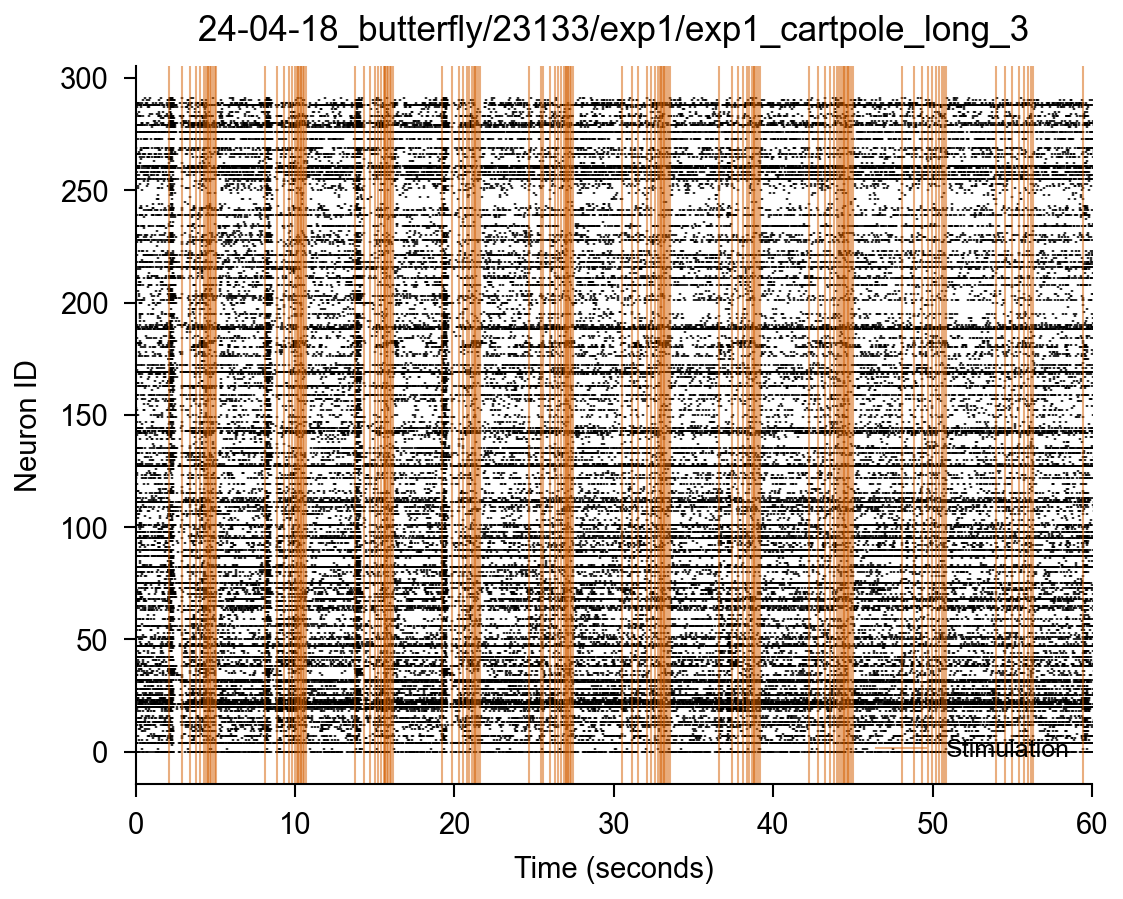

(<Figure size 1156.33x932.438 with 1 Axes>,
 (<Axes: title={'center': '24-04-18_butterfly/23133/exp1/exp1_cartpole_long_3'}, xlabel='Time (seconds)', ylabel='Neuron ID'>,
  None))

In [22]:
rec.pl.raster_with_pop(
                    time_window=(0, 60),           # First 60 seconds
                    time_unit='seconds',
                    stim_log=stim_log,             # Pass stimulation log
                    show_pop_rate=False,           
                    show_stim_markers=True,        # Show stimulation markers
                    stim_marker_style='line',      # Vertical lines at stim times
                    stim_alpha=0.5,
                    show=True
                    )

#### Detecting Stimulus-Evoked Neurons via Latencies :

Here we use the function `calculate_latencies` to acquire a list of neurons with significant responses in regards to stimulation from the HDMEA. Latencies are essentially the time (in ms) that it takes for a neuron to respond to stimuli, very small latencies suggest that a strong connection has been formed between the specific input of a neuron to it's outputs.

We are looking for neurons who's response is 1.5x baseline firing, and who's p-values are no more than 0.0001. From this we can get a list of information on each neuron along with latency statistics (mean/median/range0), and wether a neuron is first order (direct response) or second order (response through another neuron). This information can be used in later plots.

In [32]:
if stim_log is not None and len(stim_log) > 0:    
    # Calculate latencies with statistical validation
    # Returns only neurons with significant responses
    evoked_pairs = calculate_latencies(
        spikes, 
        stim_log,
        min_response_ratio=1.5,    # Response must be 1.5x baseline
        max_p_value=0.0001,        # Statistical significance threshold
        baseline_window=(-100, 0), # 100ms before stimulus
        response_window=(0, 100),  # 100ms after stimulus
        verbose=False)
    
    print(f"✓ Found {len(evoked_pairs)} stimulus-evoked neuron pairs")
    
    if len(evoked_pairs) > 0:
        # Show summary of evoked responses
        print("\nEvoked Response Summary:")
        print("-" * 50)
        
        latencies = []
        for pair_key, data in list(evoked_pairs.items())[:10]:  # Show first 10
            latency = data['onset_latency']
            ratio = data['response_ratio']
            p_val = data['p_value']
            latencies.append(latency)
            print(f"  {pair_key}:")
            print(f"    Onset latency: {latency:.1f} ms")
            print(f"    Response ratio: {ratio:.2f}x baseline")
            print(f"    P-value: {p_val:.2e}")
        
        # Overall statistics
        all_latencies = [d['onset_latency'] for d in evoked_pairs.values()]
        print(f"\nLatency Statistics (n={len(all_latencies)}):")
        print(f"  Mean: {np.mean(all_latencies):.1f} ms")
        print(f"  Median: {np.median(all_latencies):.1f} ms")
        print(f"  Range: {np.min(all_latencies):.1f} - {np.max(all_latencies):.1f} ms")
        
        # Classify response types
        immediate = sum(1 for l in all_latencies if l < 10)
        multi_order = sum(1 for l in all_latencies if l >= 10)
        print(f"\nResponse Classification:")
        print(f"  First-order (<10ms): {immediate} neurons")
        print(f"  Multi-order (≥10ms): {multi_order} neurons")
        
        # Save results
        rec.results.evoked_pairs = evoked_pairs
        rec.results.n_evoked = len(evoked_pairs)
        rec.save_results()
        print("\n✓ Latency results saved to cache")

else:
    print("\nSkipping latency analysis (no stimulation data)")

✓ Found 108 stimulus-evoked neuron pairs

Evoked Response Summary:
--------------------------------------------------
  electrode_21556_neuron_0:
    Onset latency: 1.0 ms
    Response ratio: 2.40x baseline
    P-value: 3.09e-68
  electrode_21556_neuron_1:
    Onset latency: 1.0 ms
    Response ratio: 3.20x baseline
    P-value: 3.81e-05
  electrode_21556_neuron_4:
    Onset latency: 1.0 ms
    Response ratio: 1.68x baseline
    P-value: 2.42e-16
  electrode_21556_neuron_5:
    Onset latency: 1.0 ms
    Response ratio: 3.07x baseline
    P-value: 7.89e-10
  electrode_21556_neuron_6:
    Onset latency: 1.0 ms
    Response ratio: 2.31x baseline
    P-value: 9.51e-07
  electrode_21556_neuron_11:
    Onset latency: 3.0 ms
    Response ratio: 3.13x baseline
    P-value: 1.79e-13
  electrode_21556_neuron_15:
    Onset latency: 1.0 ms
    Response ratio: 2.08x baseline
    P-value: 2.54e-12
  electrode_21556_neuron_16:
    Onset latency: 1.0 ms
    Response ratio: 3.34x baseline
    P-value: 

#### Single Neuron Evoked Response :

Here we examine the response of a single neuron to stimulation. We create a raster of our subject neuron over multiple trials (y-axis). Each trial encompasses a window of time before and after a stimulation event. This window is by default set to 100 ms on either side of the stimulation. The columns of this graph are millisecond time steps for the spike train of our subject neuron, and the rows are each of the trials. Stimulation is marked using a blue dashed-line and the initial firing of our subject neuron after stimulation is highlighted in orange, while all other spike events following the initial response are drawn in black.


Plotting example: electrode_21556_neuron_0

Creating raster plot...


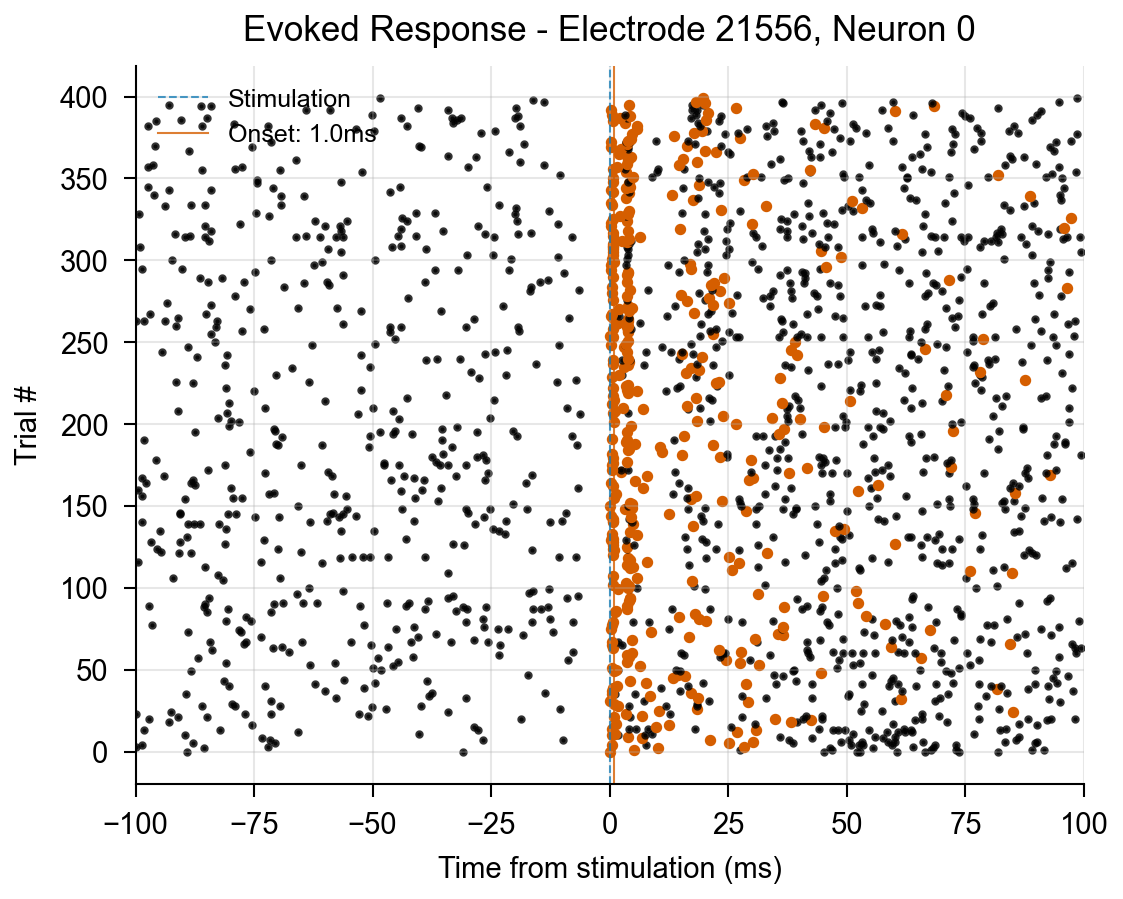

In [24]:
if stim_log is not None and len(evoked_pairs) > 0:
    # Pick the first evoked pair as an example
    example_pair_key = list(evoked_pairs.keys())[0]
    example_data = evoked_pairs[example_pair_key]

    # Parse electrode and neuron from pair key
    # Expected format: "electrode_X_neuron_Y"
    parts = example_pair_key.split('_')
    electrode_id = int(parts[1])
    neuron_idx = int(parts[3])

    print(f"\nPlotting example: {example_pair_key}")
    
    # Create the raster plot using the Recording's plot accessor
    # No need to create a Styler - the accessor handles it internally
    print("\nCreating raster plot...")
    fig_raster = rec.pl.evoked_raster(
        electrode_id=electrode_id,
        neuron_idx=neuron_idx,
        plot_window=(-100, 100),   # 100ms before and after stimulus
        max_trials=400,            # Limit for performance
        latency_data=example_data, # Overlay latency analysis results
        show=True
    )
else:
    print("\nSkipping evoked response visualization (no evoked pairs found)")

With this we see most of the initial neuron response happens within one millisecond of stimulation, however we are more interested in where the average lands than the initial. From our above graph it appears that the average response is the initial response but we can check that by creating a histogram. 

This histogram is known as the peri-stimulus time histogram (PSTH) in which we bin spike responses in that timeframe across all trials, revealing the average temporal structure of the response, something that isn't obvious just looking at the raster representation. This, in essence, shows where the majority of firings across the trials land. Along with this it also allows to gauge the general change in firing rate between the pre-stimulation and post-stimulation windows, these marked by the yellow dashed-line for pre and green dashed-line for post. This plot also includes a statistical summary of the data in the textbox at the top left.


Creating PSTH (peri-stimulus time histogram)...


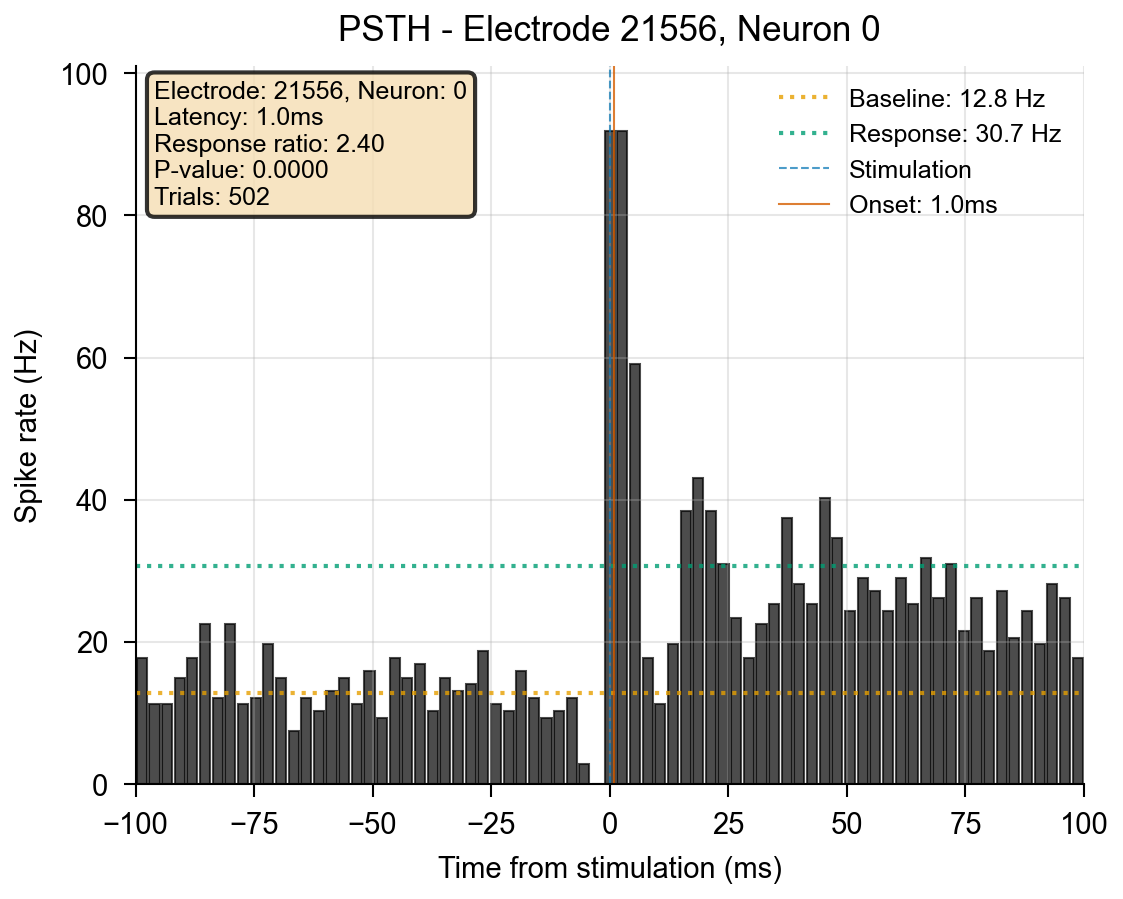

In [27]:
if stim_log is not None and len(evoked_pairs) > 0:
    # Create the PSTH plot using the Recording's plot accessor
    print("\nCreating PSTH (peri-stimulus time histogram)...")
    fig_psth = rec.pl.evoked_psth(
        electrode_id=electrode_id,
        neuron_idx=neuron_idx,
        plot_window=(-100, 100),   # Same window as raster
        max_trials=400,
        psth_bins=75,              # 75 time bins
        latency_data=example_data,
        show=True
    )

    # You can also use the recording's plot accessor:
    # fig_raster = rec.pl.evoked_raster(electrode_id=electrode_id, neuron_idx=neuron_idx)
    # fig_psth = rec.pl.evoked_psth(electrode_id=electrode_id, neuron_idx=neuron_idx)
else:
    print("\nSkipping evoked response visualization (no evoked pairs found)")

With this histogram we see two things, first we can confirm that here the majority response lands on the in the initial response as predicted. However this may not always be the case so it is important to check using the PSTH. Secondly we can see that post-stimulation the average firing rate around doubled when compared to the pre. 

Try changing the bincount to look at the data with a more magnified lense:

In [26]:
# your code here

Can you calculate the average response time in milliseconds across all trials for the dataset? 

In [ ]:
# your code here

## Saving Results

Now we can use the recording's inbuilt `results` field to save what we have calculated for later use. This allows complex computation of data to only be needed to be executed once. Once the results have been inputted to the recording field, using the command `save_results()` will save the results to disk where it can be retrieved later 

In [ ]:
rec.results.firing_rates = firing_rates
rec.results.mean_firing_rate = np.mean(firing_rates)
rec.save_results()

print("\n✓ All results saved to cache")

Now you have learned the basics of how to access and analyze data using BrainDance! Using what you learned here as a launchpad for your own bespoke analysis techniques should accelerate your ability to work with HDMEA data. Congratulations, you are now equipped to start analysis on your own experiments and test your own theories using live organoid recording data!  